# Volis Case Study - Machine Learning

Dataset: `volis_dataset.csv`

This project was developed as part of the course:

**Machine Learning: A Practical Approach with Theoretical Foundations**  
Faculty of Sciences - University of Porto (FCUP)

This notebook presents an exploratory data analysis (EDA) and unsupervised machine learning study of higher education institutions based on the Volis dataset.

The objective of the analysis is to identify structural patterns across institutions and explore how institutional characteristics relate to academic outcomes.

Main Objectives:

- Explore the structural characteristics of higher education institutions  
- Identify meaningful institutional segments using clustering techniques  
- Analyse how institutional profiles relate to graduation outcomes

## 0) Imports

In [97]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# Clustering algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering

# Dimensionality reduction
from sklearn.decomposition import PCA

# Evaluation metrics
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

import warnings
warnings.filterwarnings("ignore")

## 1) Data loading

In [98]:
# Load dataset
df = pd.read_csv("data/volis_dataset.csv")

# Display first rows
df.head()

,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
0,Goucher College,True,1151.0,813.0,248.0,40.0,64.0,850.0,80.0,15588.0,6174.0,500.0,1200.0,78.0,90.0,9.2,34.0,16623.0,77.0
1,SUNY at Albany,False,13528.0,9198.0,1843.0,16.0,61.0,10168.0,1231.0,6550.0,4355.0,700.0,1560.0,93.0,96.0,17.4,16.0,9075.0,74.0
2,Lawrence University,True,1243.0,947.0,324.0,50.0,77.0,1129.0,74.0,17163.0,3891.0,525.0,975.0,76.0,92.0,10.1,57.0,13965.0,77.0
3,East Carolina University,False,9274.0,6362.0,2435.0,14.0,44.0,13171.0,1687.0,7248.0,3240.0,500.0,1700.0,74.0,78.0,13.2,18.0,9002.0,58.0
4,Amherst College,True,4302.0,992.0,418.0,83.0,96.0,1593.0,5.0,19760.0,5300.0,660.0,1598.0,93.0,98.0,8.4,63.0,21424.0,100.0


## 2) Dataset overview

In [99]:
# Initial dataset inspection

print("\n1. Number of rows and columns")
print(df.shape)

print("\n2. Preview of the first rows:")
display(df.head())

print("\n3. Data types and metadata:")
print(df.info())

print("\n4. Descriptive statistics (central tendency and dispersion):")
# count, mean (central tendency), std (dispersion), min/max (range), quartiles (distribution)
display(df.describe())


1. Number of rows and columns
(977, 19)

2. Preview of the first rows:


,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
0,Goucher College,True,1151.0,813.0,248.0,40.0,64.0,850.0,80.0,15588.0,6174.0,500.0,1200.0,78.0,90.0,9.2,34.0,16623.0,77.0
1,SUNY at Albany,False,13528.0,9198.0,1843.0,16.0,61.0,10168.0,1231.0,6550.0,4355.0,700.0,1560.0,93.0,96.0,17.4,16.0,9075.0,74.0
2,Lawrence University,True,1243.0,947.0,324.0,50.0,77.0,1129.0,74.0,17163.0,3891.0,525.0,975.0,76.0,92.0,10.1,57.0,13965.0,77.0
3,East Carolina University,False,9274.0,6362.0,2435.0,14.0,44.0,13171.0,1687.0,7248.0,3240.0,500.0,1700.0,74.0,78.0,13.2,18.0,9002.0,58.0
4,Amherst College,True,4302.0,992.0,418.0,83.0,96.0,1593.0,5.0,19760.0,5300.0,660.0,1598.0,93.0,98.0,8.4,63.0,21424.0,100.0



3. Data types and metadata:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 977 entries, 0 to 976
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   nm_college                       977 non-null    object 
 1   bl_private                       956 non-null    object 
 2   qt_applications_received         962 non-null    float64
 3   qt_applications_accepted         955 non-null    float64
 4   qt_students_enrolled             956 non-null    float64
 5   qt_top_10_percent                956 non-null    float64
 6   qt_top_25_percent                962 non-null    float64
 7   qt_undergraduate_students        961 non-null    float64
 8   qt_postgraduate_students         960 non-null    float64
 9   vl_tuition_outstate              959 non-null    float64
 10  vl_room_board                    957 non-null    float64
 11  vl_books_cost                    958 non-null    float6

,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
count,962.000000,955.000000,956.000000,956.000000,962.000000,961.000000,960.000000,959.000000,957.000000,958.00000,965.000000,956.000000,955.000000,960.000000,961.000000,955.000000,963.000000
mean,3407.768191,2049.859686,792.927824,26.457113,52.904366,3518.034339,810.072917,12379.983316,4504.491118,604.24739,1443.190674,70.331590,75.779058,14.305208,22.551509,12425.086911,64.241952
std,8420.796455,2706.765606,1158.893541,17.123183,19.420941,5124.628362,1754.771752,45322.758310,1813.501606,698.62322,1714.550823,15.950903,16.837190,4.592944,12.597689,55674.935543,16.579696
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.100000,0.000000,1.000000,0.000000
25%,880.500000,702.000000,278.000000,17.000000,40.000000,1100.000000,131.750000,7860.000000,3700.000000,500.00000,920.000000,60.000000,60.000000,12.100000,15.000000,7086.500000,56.000000
50%,2000.000000,1500.000000,500.000000,20.000000,49.000000,2000.000000,300.000000,10000.000000,4514.000000,570.00000,1400.000000,71.000000,77.000000,14.700000,20.000000,8000.000000,60.000000
75%,2967.750000,2037.000000,724.000000,32.000000,65.000000,3051.000000,765.250000,12035.000000,5000.000000,600.00000,1525.000000,83.000000,90.000000,15.625000,29.000000,10077.000000,75.000000
max,100000.000000,26330.000000,10000.000000,100.000000,100.000000,50000.000000,21836.000000,1000000.000000,50000.000000,10000.00000,30000.000000,103.000000,100.000000,100.000000,100.000000,1000000.000000,118.000000


The dataset contains information on 977 institutions, including academic, financial, and structural variables.
Several variables related to institutional size and costs show substantial variability, suggesting the presence of skewness and potential outliers.
A small number of missing values is also observed and will be handled during the data preprocessing stage.

## 3) Data quality: missing values and duplicates

Missing values by column:

In [100]:
# Checking missing values
print("Count of missing values per column:")
print(df.isnull().sum())

Count of missing values per column:
nm_college                          0
bl_private                         21
qt_applications_received           15
qt_applications_accepted           22
qt_students_enrolled               21
qt_top_10_percent                  21
qt_top_25_percent                  15
qt_undergraduate_students          16
qt_postgraduate_students           17
vl_tuition_outstate                18
vl_room_board                      20
vl_books_cost                      19
vl_personal_expenses               12
pc_faculty_with_phd                21
pc_faculty_with_terminal_degree    22
vl_student_faculty_ratio           17
pc_alumni_donors                   16
vl_expenditure_per_student         22
pc_graduation_rate                 14
dtype: int64


Percentage of missing values per column:

,0
vl_expenditure_per_student,2.251791
pc_faculty_with_terminal_degree,2.251791
qt_applications_accepted,2.251791
qt_top_10_percent,2.149437
pc_faculty_with_phd,2.149437
bl_private,2.149437
qt_students_enrolled,2.149437
vl_room_board,2.047083
vl_books_cost,1.944729
vl_tuition_outstate,1.842375


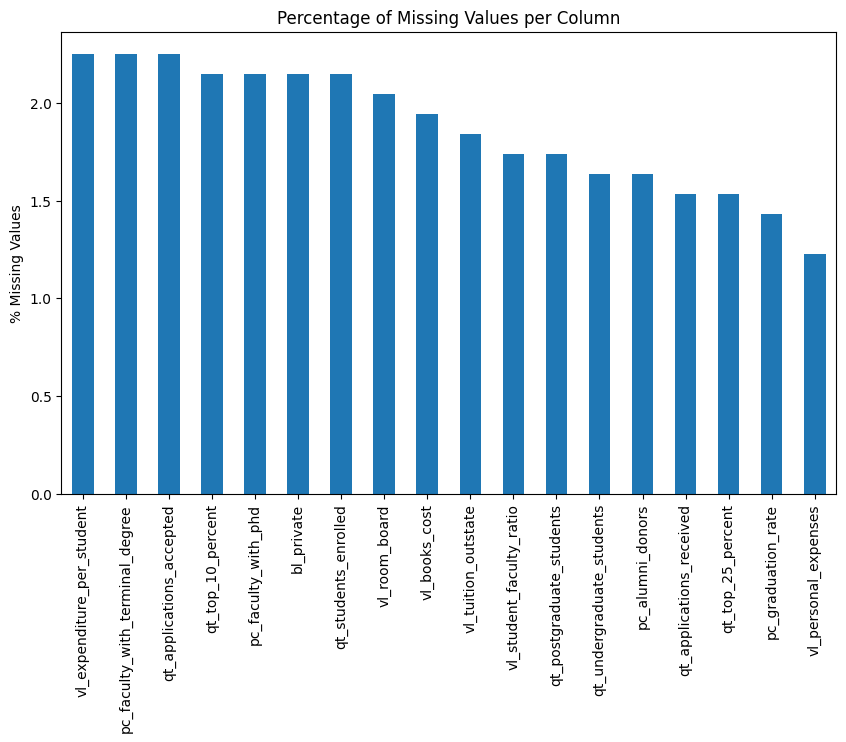

In [101]:
# Percentage of missing values
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

display(missing_percent)

plt.figure(figsize=(10,6))
missing_percent[missing_percent > 0].plot(kind="bar")
plt.ylabel("% Missing Values")
plt.title("Percentage of Missing Values per Column")
plt.show()

In [102]:
# Overall percentage of missing values in the dataset
total_nan = df.isna().sum().sum()
total_cells = df.shape[0] * df.shape[1]
nan_percent = (total_nan / total_cells) * 100

print("Overall percentage of NaN values:", round(nan_percent, 2), "%")


# Rows affected by missing values
rows_with_nan = df.isna().any(axis=1).sum()

print("Rows with at least one NaN:", rows_with_nan)
print("Percentage of affected rows:",
      round(rows_with_nan / len(df) * 100, 2), "%")

Overall percentage of NaN values: 1.77 %
Rows with at least one NaN: 160
Percentage of affected rows: 16.38 %


The overall percentage of missing values in the dataset is relatively low (~1.77%).
However, about 16% of the observations contain at least one missing value.
Removing these observations would reduce the available sample size, potentially discarding useful information.
Therefore, missing values will be handled through median imputation in the preprocessing stage,
as this approach preserves the full dataset while remaining robust to outliers.

This strategy ensures that the clustering analysis is performed on a complete dataset without introducing strong biases from extreme values.

Duplicate rows:

In [103]:
# Check for duplicated rows
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


No duplicated observations were found in the dataset, indicating that each row represents a unique institution.

## 4) EDA: distributions and outliers

Since clustering algorithms rely on distance calculations, highly skewed variables can disproportionately influence the grouping process.

In [104]:
# Skewness analysis
skew_values = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
display(skew_values)

,0
vl_tuition_outstate,21.645997
vl_expenditure_per_student,17.588918
vl_room_board,16.502555
vl_personal_expenses,14.465426
vl_books_cost,12.758081
qt_applications_received,9.708450
qt_postgraduate_students,7.148774
vl_student_faculty_ratio,6.955577
qt_students_enrolled,4.786548
qt_undergraduate_students,4.196566


The skewness analysis shows that several financial and institutional size variables exhibit strong positive skewness (e.g., tuition, expenditure per student, and number of applications).
This indicates right-tailed distributions and the presence of extreme high values.

In contrast, most percentage variables present low or slightly negative skewness, suggesting more balanced distributions.

These results justify the use of logarithmic transformations for the most skewed variables before applying clustering, in order to reduce the influence of extreme values and improve the comparability between institutions.

Outlier identification (IQR criterion):

In [105]:
# Outliers
# Formal identification using the IQR criterion

def count_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return ((col < lower) | (col > upper)).sum()


outlier_counts = {}

for col in df.select_dtypes(include=np.number).columns:
    outlier_counts[col] = count_outliers(df[col])

outliers_df = pd.Series(outlier_counts).sort_values(ascending=False)

display(outliers_df)

,0
qt_undergraduate_students,141
qt_students_enrolled,135
qt_applications_received,112
qt_applications_accepted,107
qt_postgraduate_students,100
vl_expenditure_per_student,98
vl_books_cost,79
qt_top_10_percent,71
vl_student_faculty_ratio,70
vl_personal_expenses,59


To identify potential extreme values, the interquartile range (IQR) criterion was applied.
This method flags observations that fall outside the interval defined by 1.5 × IQR below the first quartile or above the third quartile.

The results show that variables related to institutional size and student counts tend to concentrate a higher number of outliers, which is consistent with the substantial variability observed across institutions.

These extreme values may represent institutions with very different scales or characteristics.
Therefore, instead of removing them, their impact is addressed through appropriate transformations and robust scaling techniques during preprocessing.

To facilitate interpretation, numerical variables were grouped according to their scale and nature (count variables, monetary variables, and percentage/ratio variables). This grouping allows more meaningful comparisons between variables with similar magnitudes.

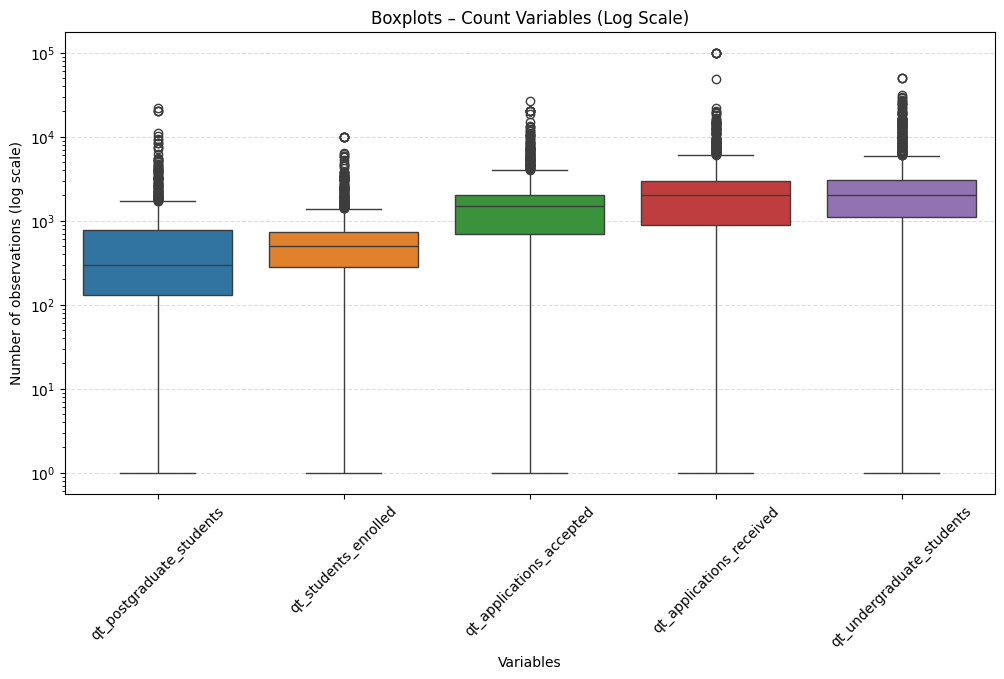

In [106]:
# Count variables (institution size and application metrics)
cols_contagem = [
    "qt_applications_received",
    "qt_applications_accepted",
    "qt_students_enrolled",
    "qt_undergraduate_students",
    "qt_postgraduate_students"
]

# Create a copy for visualization
df_plot = df[cols_contagem].copy()

# Replace zeros with 1 for visualization only
# (log scale cannot represent zero values)
df_plot = df_plot.replace(0, 1)

# Order variables by median to improve interpretability
order = df_plot.median().sort_values().index

plt.figure(figsize=(12,6))

sns.boxplot(data=df_plot[order])

# Log scale improves visualization of highly skewed count variables
plt.yscale("log")

plt.xticks(rotation=45)

plt.title("Boxplots – Count Variables (Log Scale)")
plt.ylabel("Number of observations (log scale)")
plt.xlabel("Variables")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The count variables show large ranges and strong right-skewed distributions, with some institutions presenting substantially higher values than others. To improve readability and enable clearer comparisons across variables, the boxplots are displayed using a logarithmic scale, which helps visualize both the central distributions and the presence of extreme values.

As variáveis de contagem apresentam elevada dispersão e múltiplos outliers, refletindo a grande heterogeneidade na dimensão das instituições (número de estudantes e candidaturas).

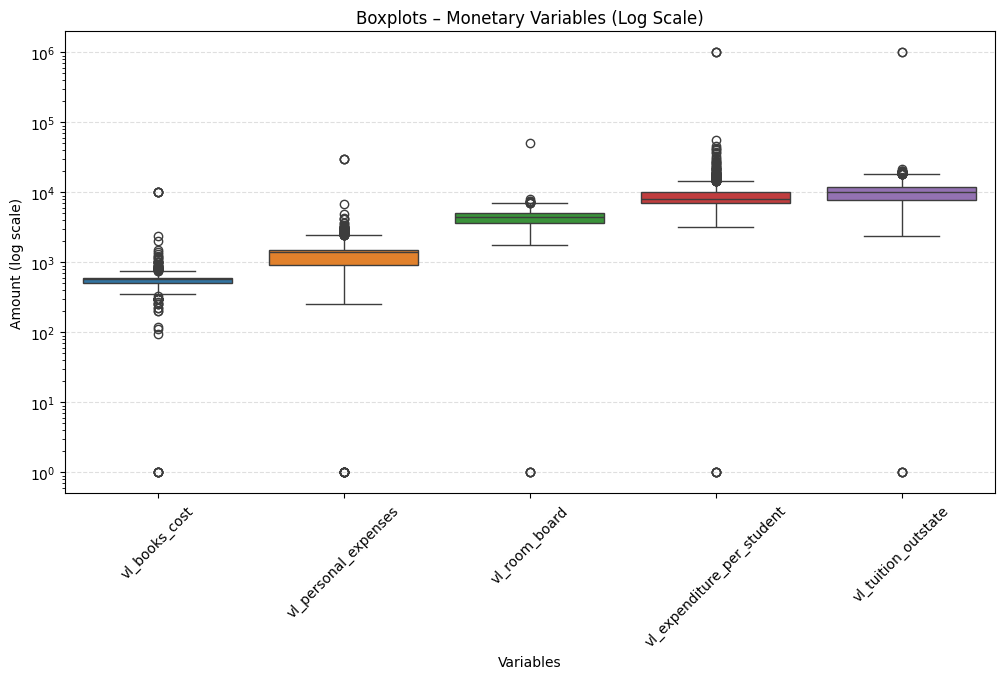

In [107]:
# Monetary variables (institutional costs and expenditures)
cols_monetarias = [
    "vl_tuition_outstate",
    "vl_room_board",
    "vl_books_cost",
    "vl_personal_expenses",
    "vl_expenditure_per_student"
]

# Copy data for visualization
df_plot = df[cols_monetarias].copy()

# Replace zeros with 1 for visualization only (log scale cannot display zero)
df_plot = df_plot.replace(0, 1)

# Order variables by median to improve interpretability
order = df_plot.median().sort_values().index

plt.figure(figsize=(12,6))

sns.boxplot(data=df_plot[order])

# Log scale improves visualization of highly skewed monetary variables
plt.yscale("log")

plt.xticks(rotation=45)

plt.title("Boxplots – Monetary Variables (Log Scale)")
plt.ylabel("Amount (log scale)")
plt.xlabel("Variables")

# Soft grid for easier interpretation
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

Monetary variables display substantial variability across institutions and exhibit strong right-skewed distributions. To improve readability and enable clearer comparisons between variables with large value ranges, the boxplots are displayed using a logarithmic scale.

In [108]:
cols_percent = [
    "qt_top_10_percent",
    "qt_top_25_percent",
    "pc_faculty_with_phd",
    "pc_faculty_with_terminal_degree",
    "pc_alumni_donors",
    "pc_graduation_rate",
    "vl_student_faculty_ratio"
]

To better understand the distribution of percentage-based variables, boxplots are used to visualize their dispersion and identify potential outliers.

The student-faculty ratio is displayed separately because it represents a different type of metric and operates on a different scale. Plotting it together with percentage variables could distort the visual interpretation of the distributions.

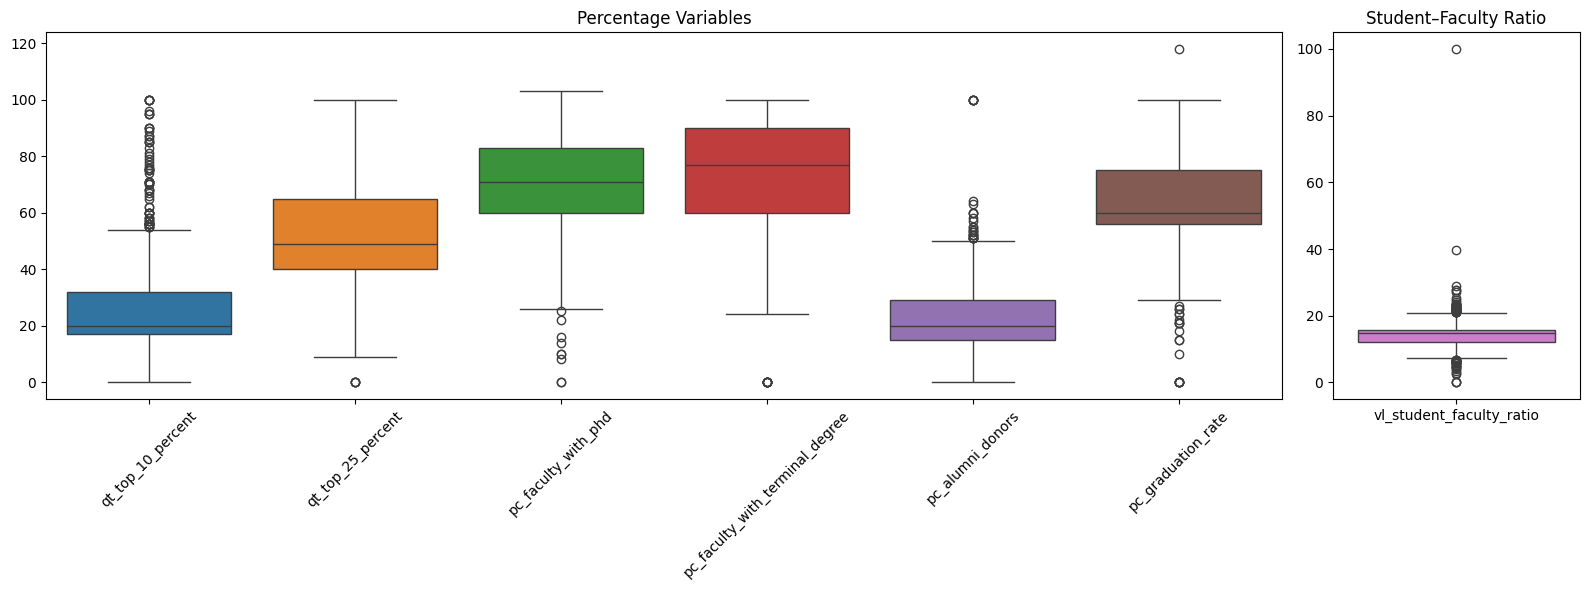

In [109]:
# Create figure with two panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), gridspec_kw={'width_ratios':[5,1]})

# Percentage variables
sns.boxplot(data=df[cols_percent[:-1]], ax=ax1)
ax1.set_title("Percentage Variables")
ax1.tick_params(axis="x", rotation=45)

# Student–faculty ratio
sns.boxplot(data=df[["vl_student_faculty_ratio"]], ax=ax2, color="orchid")
ax2.set_title("Student–Faculty Ratio")

plt.tight_layout()
plt.show()

The boxplots indicate moderate dispersion across most percentage variables. Some institutions exhibit higher levels of selectivity, faculty qualification, and graduation rates compared to the majority of the dataset.

The student-faculty ratio presents a distinct scale and distribution relative to the percentage variables, which justifies analyzing it separately.

Percentage variables are theoretically bounded between 0 and 100. Therefore, it is important to verify whether any observations exceed this logical limit, which could indicate data entry errors or inconsistencies in the dataset.

In [110]:
(df[cols_percent] > 100).sum()

,0
qt_top_10_percent,0
qt_top_25_percent,0
pc_faculty_with_phd,1
pc_faculty_with_terminal_degree,0
pc_alumni_donors,0
pc_graduation_rate,1
vl_student_faculty_ratio,0


The inspection shows that only a very small number of observations exceed the expected upper bound of 100%.

Although these cases are rare, they violate the logical constraints of percentage variables and should be corrected or treated before further analysis.

After examining the distributions and potential outliers in the variables, the next step is to explore the relationships between them.

In particular, we investigate which institutional characteristics appear to be associated with the graduation rate (*pc_graduation_rate*), an important indicator of academic performance.

## 5) Which variables are associated with *pc_graduation_rate*?

Correlation analysis among numerical variables:

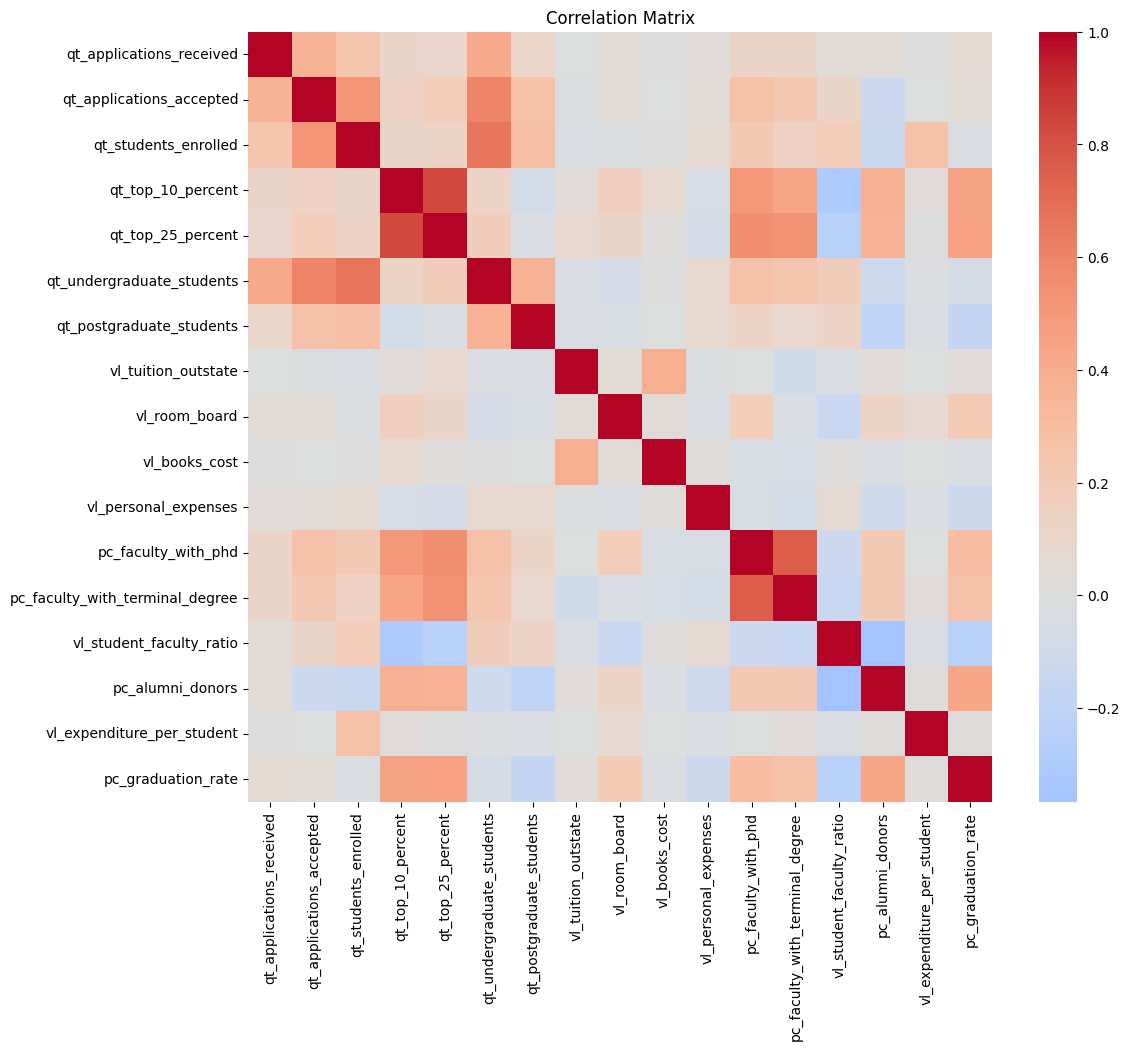

In [111]:
# Relationships between variables
# Full correlation matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

Correlation with the target variable (*pc_graduation_rate*):

In [112]:
# Focus on the target variable
corr["pc_graduation_rate"].sort_values(ascending=False)

,pc_graduation_rate
pc_graduation_rate,1.000000
qt_top_25_percent,0.456382
qt_top_10_percent,0.448347
pc_alumni_donors,0.437683
pc_faculty_with_phd,0.308635
pc_faculty_with_terminal_degree,0.264839
vl_room_board,0.205208
qt_applications_received,0.059874
qt_applications_accepted,0.049488
vl_tuition_outstate,0.031825


**So... which variables appear to be associated with *pc_graduation_rate*?**

The correlation analysis indicates that the variables most strongly associated with the graduation rate (*pc_graduation_rate*) are *qt_top_25_percent*, *qt_top_10_percent*, *pc_alumni_donors*, and *pc_faculty_with_phd*, all showing moderate positive correlations. This suggests that institutions with higher selectivity and better-qualified faculty tend to achieve higher graduation rates.

A negative correlation is also observed with the student-faculty ratio, indicating that smaller class sizes may be associated with better academic outcomes.

No unexpected relationships are identified, as the observed associations are consistent with academic and structural factors typically linked to student success.

However, there is a potential risk of spurious correlation, since several of these variables may reflect a common underlying factor such as institutional prestige or overall educational quality. Therefore, the observed correlations may represent indirect effects rather than direct causal relationships.

## 6) Are there structural differences between private and public institutions in terms of costs, academic selectivity, and graduation rates?

To investigate this question, a comparison is conducted between private and public institutions focusing on three key dimensions: institutional costs, academic selectivity, and graduation outcomes.

Both visual exploration (boxplots) and numerical summaries are used to identify potential structural differences between the two groups of institutions.

Tuition distribution (Private vs Public):

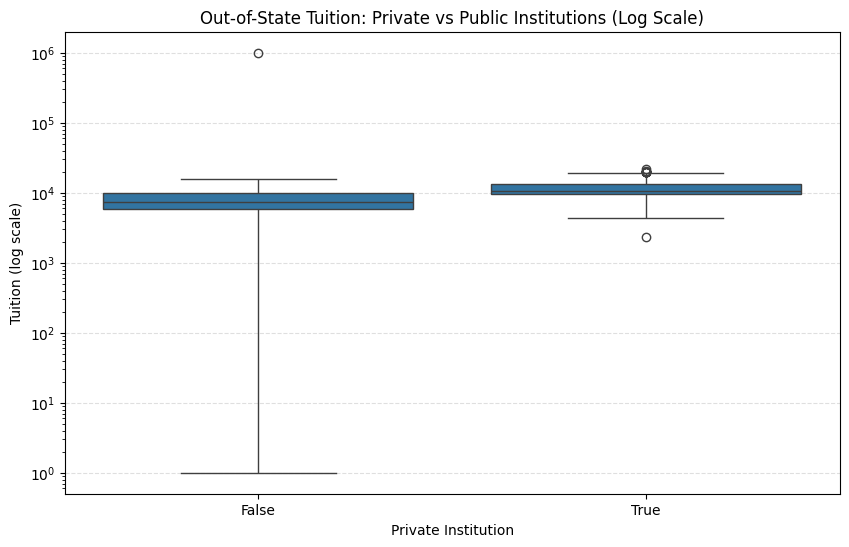

In [113]:
# Tuition distribution (Private vs Public)

plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="bl_private", y="vl_tuition_outstate")

# Log scale improves visualization due to strong skewness
plt.yscale("log")

plt.title("Out-of-State Tuition: Private vs Public Institutions (Log Scale)")
plt.xlabel("Private Institution")
plt.ylabel("Tuition (log scale)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

The distribution suggests that, on average, private institutions tend to exhibit slightly higher tuition levels than public institutions. However, there is substantial overlap between the two groups, indicating that tuition fees alone are not a strong differentiating factor.

An extreme outlier is visible among public institutions, with a tuition value far above the typical range observed in the dataset. Such a value is unusual for public institutions and may reflect a data entry error, a misrecorded value (for example, an extra digit), or a specific institutional pricing structure that differs from the majority of observations.

Since this stage focuses on exploratory analysis rather than data preparation, the observation is temporarily retained. The potential anomaly will be examined and treated during the data preprocessing stage.

Academic Selectivity (Top 25%) by Institution Type:

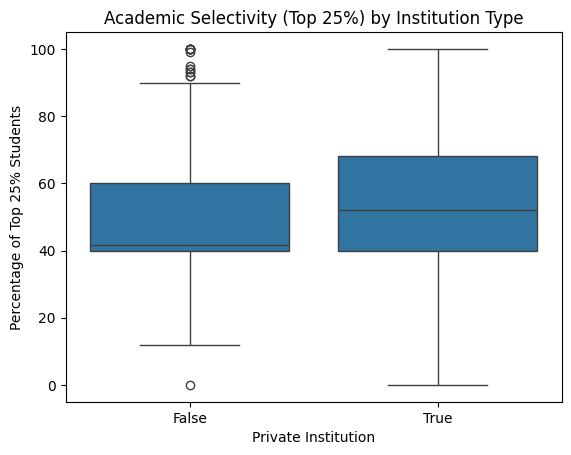

In [114]:
sns.boxplot(data=df, x="bl_private", y="qt_top_25_percent")
plt.title("Academic Selectivity (Top 25%) by Institution Type")
plt.xlabel("Private Institution")
plt.ylabel("Percentage of Top 25% Students")
plt.show()

Private institutions tend to display a higher proportion of students originating from the top 25% of their high school class. This pattern suggests that, on average, private institutions may exhibit slightly higher academic selectivity.

Nevertheless, there is still noticeable overlap between the two distributions, indicating that selectivity varies considerably within both private and public institutions.

Graduation Rate by Institution Type:

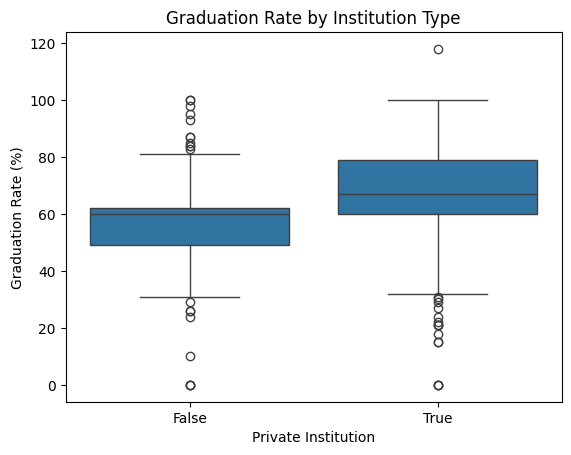

In [115]:
sns.boxplot(data=df, x="bl_private", y="pc_graduation_rate")
plt.title("Graduation Rate by Institution Type")
plt.xlabel("Private Institution")
plt.ylabel("Graduation Rate (%)")
plt.show()

The median graduation rate appears to be higher for private institutions, suggesting stronger completion outcomes on average.

However, the dispersion of values within both groups indicates that institutional performance varies widely, and the type of institution alone does not fully explain differences in graduation rates.

To complement the visual inspection, the mean value of selected variables is calculated for each institution type. Both the absolute and relative differences between private and public institutions are then examined to quantify the patterns observed in the plots.

In [116]:
# Select relevant variables
vars_comparacao = [
    "vl_tuition_outstate",
    "vl_expenditure_per_student",
    "qt_top_25_percent",
    "pc_graduation_rate"
]

df.groupby("bl_private")[vars_comparacao].mean()

,vl_tuition_outstate,vl_expenditure_per_student,qt_top_25_percent,pc_graduation_rate
bl_private,,,,
False,10984.242215,14525.228873,49.768966,56.624138
True,11566.087692,10117.780675,54.664110,67.743119


In [117]:
# Calculate group means
medias = df.groupby("bl_private")[vars_comparacao].mean()

# Absolute difference
diferenca = medias.loc[True] - medias.loc[False]
diferenca

,0
vl_tuition_outstate,581.845478
vl_expenditure_per_student,-4407.448198
qt_top_25_percent,4.895145
pc_graduation_rate,11.118981


In [118]:
(diferenca / medias.loc[False]) * 100

,0
vl_tuition_outstate,5.297093
vl_expenditure_per_student,-30.343399
qt_top_25_percent,9.835738
pc_graduation_rate,19.636469


**Conclusion:**
The results suggest that structural differences exist between private and public institutions. On average, private institutions show higher academic selectivity (a larger share of students from the top 25% of their class) and higher graduation rates. Tuition levels are also slightly higher among private institutions.

Interestingly, the average expenditure per student appears lower for private institutions, which may reflect differences in funding structures, institutional size, or operational models.

Despite these average differences, the distributions reveal substantial overlap between private and public institutions. This suggests that institutional type alone does not fully determine academic outcomes, and other factors (such as institutional resources, student composition, or organizational characteristics) may also play an important role.

## 7) Data Pre-processing




Before applying clustering techniques, a preprocessing stage is performed to ensure that the dataset is consistent and suitable for distance-based algorithms.

Extreme anomalies and logically inconsistent values identified during the exploratory analysis are addressed in order to reduce noise and prevent distortion in the clustering results.

In particular, two types of issues are corrected:

- Unrealistic tuition values, including extreme observations exceeding plausible ranges for higher education institutions.  
- Percentage variables exceeding logical bounds (above 100%), which violate the definition of percentage-based metrics.

Removing or correcting these anomalies helps ensure that the clustering algorithm focuses on meaningful structural patterns rather than artefacts of data quality issues.

In [119]:
df[df["vl_tuition_outstate"] > 100000]

,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate
66,Emily Dickinson College,False,2000.0,1500.0,500.0,20.0,40.0,2000.0,NaN,1000000.0,5000.0,600.0,1500.0,60.0,0.0,15.0,20.0,8000.0,60.0
469,Karl Marx University,NaN,2000.0,1500.0,500.0,20.0,100.0,2000.0,300.0,1000000.0,5000.0,10000.0,1500.0,60.0,60.0,15.0,20.0,8000.0,60.0


In [120]:
(df[cols_percent] > 100).sum()

,0
qt_top_10_percent,0
qt_top_25_percent,0
pc_faculty_with_phd,1
pc_faculty_with_terminal_degree,0
pc_alumni_donors,0
pc_graduation_rate,1
vl_student_faculty_ratio,0


**Outlier Removal:**

Based on the anomalies detected during the exploratory analysis, rows containing logically inconsistent percentage values (greater than 100%) and extreme tuition values are removed.

These observations likely result from data entry errors or recording inconsistencies and could disproportionately influence distance-based clustering algorithms such as K-Means.

The diagnostic step below first identifies problematic observations and then removes them from the dataset to ensure that subsequent analysis is based on reliable and interpretable data.

In [121]:
# --- 1. Identify Variables ---
percent_cols = [
    "qt_top_10_percent", "qt_top_25_percent", "pc_faculty_with_phd",
    "pc_faculty_with_terminal_degree", "pc_alumni_donors", "pc_graduation_rate"
]

# --- 2. Diagnostic BEFORE Cleaning ---
# This will only show values > 0 if you have just loaded the raw CSV
print("--- [DIAGNOSTIC] Errors found in raw data ---")
print(f"Total rows with percentages > 100%: {(df[percent_cols] > 100).any(axis=1).sum()}")
print((df[percent_cols] > 100).sum())
print(f"Total rows with tuition > 100k:    {(df['vl_tuition_outstate'] > 100000).sum()}")

# --- 3. Cleaning Execution ---
# Keep only rows where ALL percentages are <= 100
df = df[df[percent_cols].le(100).all(axis=1)].copy()

# Keep only rows where tuition is within a realistic range
df = df[df['vl_tuition_outstate'] < 100000].copy()

# --- 4. Diagnostic AFTER Cleaning ---
print("\n--- [VERIFICATION] Errors remaining after cleaning ---")
print((df[percent_cols] > 100).sum())
print(f"Tuition > 100k: {(df['vl_tuition_outstate'] > 100000).sum()}")

print(f"\nFinal dataset shape for pre-processing: {df.shape}")

--- [DIAGNOSTIC] Errors found in raw data ---
Total rows with percentages > 100%: 2
qt_top_10_percent                  0
qt_top_25_percent                  0
pc_faculty_with_phd                1
pc_faculty_with_terminal_degree    0
pc_alumni_donors                   0
pc_graduation_rate                 1
dtype: int64
Total rows with tuition > 100k:    2

--- [VERIFICATION] Errors remaining after cleaning ---
qt_top_10_percent                  0
qt_top_25_percent                  0
pc_faculty_with_phd                0
pc_faculty_with_terminal_degree    0
pc_alumni_donors                   0
pc_graduation_rate                 0
dtype: int64
Tuition > 100k: 0

Final dataset shape for pre-processing: (879, 19)


In [122]:
df[df["vl_tuition_outstate"] > 100000]

,nm_college,bl_private,qt_applications_received,qt_applications_accepted,qt_students_enrolled,qt_top_10_percent,qt_top_25_percent,qt_undergraduate_students,qt_postgraduate_students,vl_tuition_outstate,vl_room_board,vl_books_cost,vl_personal_expenses,pc_faculty_with_phd,pc_faculty_with_terminal_degree,vl_student_faculty_ratio,pc_alumni_donors,vl_expenditure_per_student,pc_graduation_rate


**Handling Missing Values:**

To preserve as many observations as possible for subsequent analysis, missing values are imputed using the median of each variable.

The median is preferred over the mean because it is more robust to skewed distributions and residual outliers identified during the exploratory analysis.

This approach allows the dataset to remain complete while minimizing the risk of introducing bias from extreme values.

In [123]:
# Identify all numeric columns for processing
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# We use SimpleImputer to fill NaNs across the entire dataset
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df[numeric_cols]), columns=numeric_cols)

print(f"Missing values after imputation: {df_imputed.isnull().sum().sum()}")

Missing values after imputation: 0


**Feature Transformation (Log Scaling):**

Several count and monetary variables in the dataset exhibit strong right-skewed distributions, which is common in institutional and financial data.

To mitigate this effect, a logarithmic transformation of the form log(x + 1) is applied to selected variables. This transformation reduces the influence of extreme values and compresses the scale of large observations.

Stabilizing the variance of these variables is particularly important for distance-based algorithms such as K-Means, which are sensitive to differences in scale across features.

Percentage and ratio variables are excluded from this transformation because they are already bounded or naturally scaled.

In [124]:
# Define which columns should receive log transformation (Counts and Monetary)
# Percentages and ratios are excluded as they are already bounded or naturally scaled
log_features = [
    'qt_applications_received', 'qt_applications_accepted', 'qt_students_enrolled',
    'qt_undergraduate_students', 'qt_postgraduate_students', 'vl_tuition_outstate',
    'vl_room_board', 'vl_books_cost', 'vl_personal_expenses', 'vl_expenditure_per_student'
]

# np.log1p handles potential zero values safely
df_transformed = df_imputed.copy()
df_transformed[log_features] = np.log1p(df_transformed[log_features])

**Global Feature Scaling:**

After feature transformation, all variables are scaled using Robust Scaling.

Unlike standard normalization techniques, the Robust Scaler relies on the interquartile range (IQR) rather than the mean and standard deviation. This makes the scaling procedure less sensitive to remaining extreme observations.

Applying a global scaling step ensures that all features contribute comparably to the clustering process, preventing variables with larger numeric ranges from dominating the distance calculations.

In [125]:
# This ensures all features (percentages, logs of counts, etc.) are on a comparable scale
scaler = RobustScaler()
df_scaled_array = scaler.fit_transform(df_transformed)

# Convert back to a clean DataFrame for easy feature selection later
df_final = pd.DataFrame(df_scaled_array, columns=numeric_cols)

print("Global preprocessing complete. Dataset is ready for feature subset selection.")

Global preprocessing complete. Dataset is ready for feature subset selection.


## 8) Feature Selection

To capture different perspectives of institutional structure, the clustering analysis is conducted using two distinct feature sets.

The first set focuses on structural and academic infrastructure, representing internal institutional capacity such as faculty qualification, institutional resources, and student selectivity.

The second set reflects market positioning and performance outcomes, incorporating variables related to financial cost, institutional reputation, and student success indicators.

Using two feature configurations allows us to evaluate the stability and robustness of the clustering results, testing whether institutions group consistently based on internal characteristics or if alternative patterns emerge when considering financial and outcome-based indicators.

In [126]:
# Experimenting with Set 1
set_1_features = ["qt_undergraduate_students", "vl_expenditure_per_student", "qt_top_25_percent", "pc_faculty_with_phd", "vl_student_faculty_ratio"]
data_cluster_1 = df_final[set_1_features]

# Experimenting with Set 2
set_2_features = ["vl_tuition_outstate", "pc_graduation_rate", "pc_alumni_donors", "qt_applications_received", "vl_room_board"]
data_cluster_2 = df_final[set_2_features]

## 9) Clustering Analysis

**Determining the Number of Clusters (Elbow Method):**

Before fitting the clustering model, it is necessary to determine an appropriate number of clusters (k). To guide this decision, the Elbow Method is applied.

This method evaluates the within-cluster sum of squared distances (inertia) for different values of k. As the number of clusters increases, inertia naturally decreases because each cluster becomes more compact. However, after a certain point, the improvement becomes marginal.

The optimal value of k is typically identified at the point where the curve begins to flatten, forming an “elbow”, which indicates diminishing returns from adding additional clusters.

To assess the robustness of the clustering structure, the Elbow Method is applied separately to both feature sets.

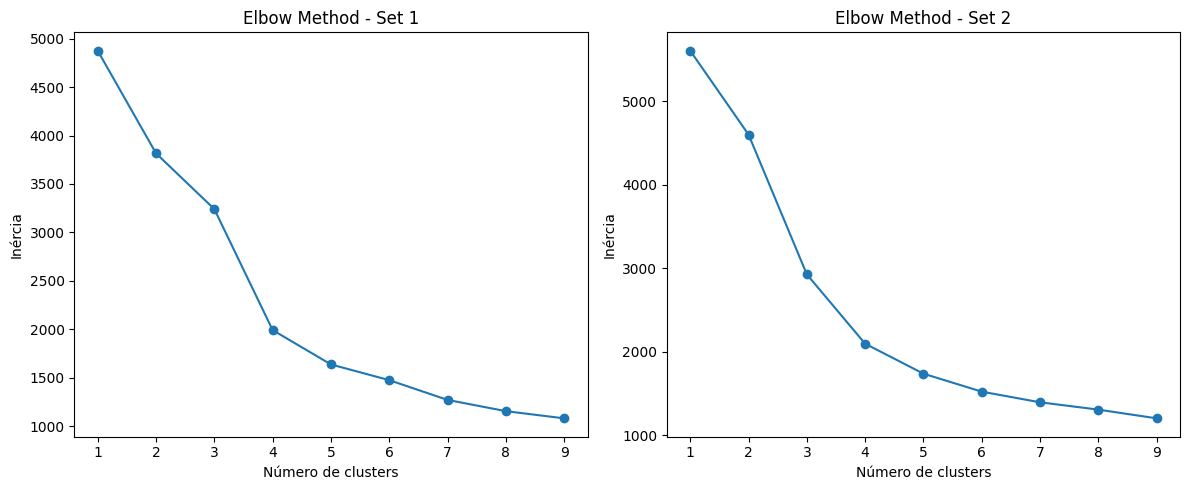

In [127]:
inertia1 = []
inertia2 = []
k_range = range(1, 10)

for k in k_range:

    kmeans1 = KMeans(n_clusters=k, random_state=42)
    kmeans1.fit(data_cluster_1)
    inertia1.append(kmeans1.inertia_)

    kmeans2 = KMeans(n_clusters=k, random_state=42)
    kmeans2.fit(data_cluster_2)
    inertia2.append(kmeans2.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(k_range, inertia1, marker='o')
axes[0].set_title("Elbow Method - Set 1")
axes[0].set_xlabel("Número de clusters")
axes[0].set_ylabel("Inércia")

axes[1].plot(k_range, inertia2, marker='o')
axes[1].set_title("Elbow Method - Set 2")
axes[1].set_xlabel("Número de clusters")
axes[1].set_ylabel("Inércia")

plt.tight_layout()
plt.show()

The elbow analysis suggests a similar pattern for both feature sets. In each case, inertia decreases sharply up to **k = 4**, after which the rate of improvement becomes substantially smaller.

This behaviour indicates that four clusters provide a reasonable balance between model simplicity and explanatory power. Consequently, k = 4 is selected for the subsequent clustering analysis in both feature configurations.

**K-Means Clustering:**

After determining the appropriate number of clusters, the K-Means algorithm is applied to both feature sets using k = 4.

The algorithm partitions the institutions into groups by minimizing the distance between observations and their respective cluster centroids. A fixed random seed is used to ensure reproducibility of the clustering results.

In [128]:
k = 4

# KMEANS
kmeans1 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters1 = kmeans1.fit_predict(data_cluster_1)

kmeans2 = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters2 = kmeans2.fit_predict(data_cluster_2)

**Cluster Quality Evaluation:**

To assess the quality of the clustering results, three commonly used internal validation metrics are calculated:

-  **Silhouette Score** -  measures how well each observation fits within its assigned cluster compared to other clusters. Higher values indicate better separation.  

-  **Calinski-Harabasz Index** -  evaluates the ratio between between-cluster dispersion and within-cluster dispersion. Higher values indicate more distinct clusters.  

-  **Davies-Bouldin Index** - measures the similarity between clusters based on their dispersion and separation. Lower values indicate better clustering performance.

In [129]:
# METRICS
metrics = pd.DataFrame({
    "Dataset": ["Set 1", "Set 2"],
    "Silhouette": [
        silhouette_score(data_cluster_1, clusters1),
        silhouette_score(data_cluster_2, clusters2)
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(data_cluster_1, clusters1),
        calinski_harabasz_score(data_cluster_2, clusters2)
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(data_cluster_1, clusters1),
        davies_bouldin_score(data_cluster_2, clusters2)
    ]
})

**Cluster Visualization using PCA:**

To facilitate visual interpretation of the clustering results, Principal Component Analysis (PCA) is applied to project the high-dimensional feature space into two principal components.

This dimensionality reduction technique allows the clusters to be visualized in a two-dimensional space while preserving as much of the variance in the data as possible.

Cluster centroids are also projected onto the same PCA space to illustrate the relative position of each group.

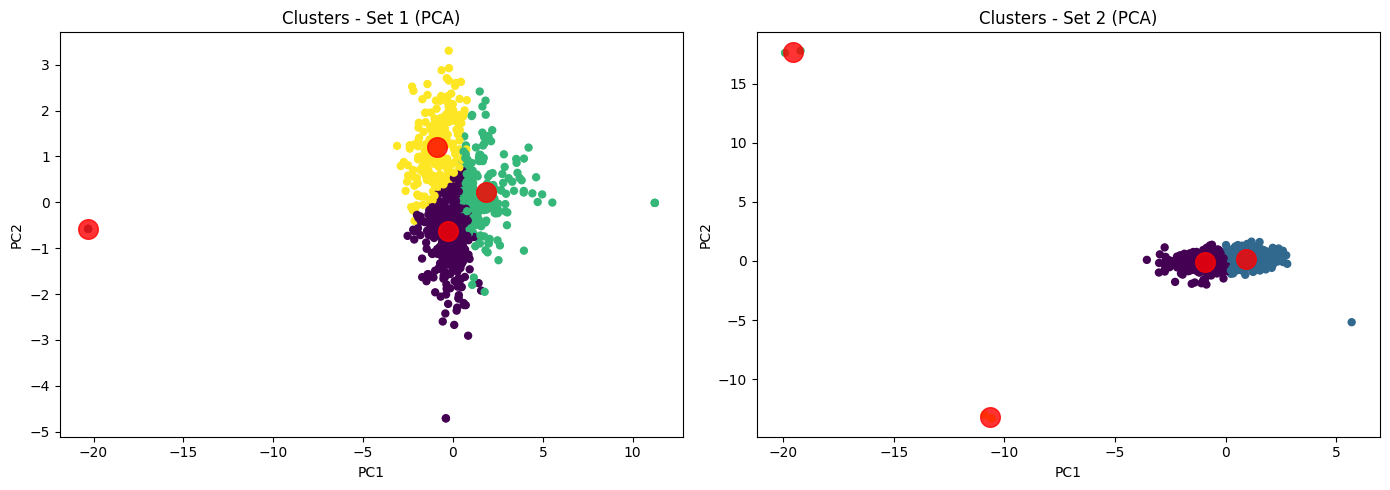

In [130]:
# PCA
pca1 = PCA(n_components=2)
X1_pca = pca1.fit_transform(data_cluster_1)

pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(data_cluster_2)

centers1_pca = pca1.transform(kmeans1.cluster_centers_)
centers2_pca = pca2.transform(kmeans2.cluster_centers_)

# ---------- VISUALIZATION ----------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Set 1
axes[0].scatter(X1_pca[:,0], X1_pca[:,1],
                c=clusters1, cmap="viridis", s=25)

axes[0].scatter(centers1_pca[:,0], centers1_pca[:,1],
                c="red", s=200, alpha=0.8)

axes[0].set_title("Clusters - Set 1 (PCA)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Set 2
axes[1].scatter(X2_pca[:,0], X2_pca[:,1],
                c=clusters2, cmap="viridis", s=25)

axes[1].scatter(centers2_pca[:,0], centers2_pca[:,1],
                c="red", s=200, alpha=0.8)

axes[1].set_title("Clusters - Set 2 (PCA)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [131]:
# SHOW METRICS
print(metrics)

  Dataset  Silhouette  Calinski-Harabasz  Davies-Bouldin
0   Set 1    0.297265         422.859415        0.923841
1   Set 2    0.270403         493.242647        0.765102


The results indicate that both feature sets produce comparable clustering structures.

Feature Set 2 achieves slightly better values for the Calinski-Harabasz index and a lower Davies-Bouldin score, suggesting marginally improved cluster separation and compactness. However, the Silhouette scores remain relatively modest for both configurations, indicating that the cluster boundaries are not perfectly distinct.

This outcome is not unexpected given the continuous nature of institutional characteristics, where institutions may lie along gradual structural gradients rather than forming perfectly separated groups.

Finally, the cluster assignments from both models are stored in the dataset to enable further comparative analysis and cluster profiling:

In [132]:
df_clusters = df_final.copy()

df_clusters["cluster_set1"] = clusters1
df_clusters["cluster_set2"] = clusters2

**Distribution of Institutions Across Clusters:**

Before interpreting the clusters, it is useful to examine the number of institutions assigned to each group.

This distribution helps assess whether the clustering algorithm produced balanced segments or whether some clusters represent rare or atypical institutional profiles.

In [133]:
print("Distribution - Set 1")
print(df_clusters["cluster_set1"].value_counts().sort_index())

print("\nDistribution - Set 2")
print(df_clusters["cluster_set2"].value_counts().sort_index())

Distribution - Set 1
cluster_set1
0    468
1      3
2    200
3    208
Name: count, dtype: int64

Distribution - Set 2
cluster_set2
0    393
1    480
2      2
3      4
Name: count, dtype: int64


**Structural Characterization of Clusters:**

To interpret the clusters, the mean value of each feature within each group is calculated.

Since the variables were previously scaled during preprocessing, the reported values represent relative positions compared to the overall dataset mean, rather than the original units of measurement. Positive values indicate that the cluster is above the dataset average for a given variable, while negative values indicate below-average values.

This summary allows us to identify the structural characteristics that differentiate each cluster.

In [134]:
cluster_summary_set1 = df_clusters.groupby("cluster_set1")[set_1_features].mean()
cluster_summary_set1

,qt_undergraduate_students,vl_expenditure_per_student,qt_top_25_percent,pc_faculty_with_phd,vl_student_faculty_ratio
cluster_set1,,,,,
0,-0.407003,-0.029360,-0.191516,-0.432692,-0.122609
1,0.030917,-21.069368,-0.407407,-0.541667,0.214286
2,0.186437,1.693547,0.902963,0.615208,-0.763571
3,0.948484,-0.495595,0.035613,0.078325,1.059638


In [135]:
cluster_summary_set2 = df_clusters.groupby("cluster_set2")[set_2_features].mean()
cluster_summary_set2

,vl_tuition_outstate,pc_graduation_rate,pc_alumni_donors,qt_applications_received,vl_room_board
cluster_set2,,,,,
0,-0.687234,-0.440325,-0.242207,-0.218021,-0.613368
1,0.448154,0.501885,0.497266,0.065693,0.433739
2,0.000000,-1.571429,0.000000,0.079233,-26.635336
3,-17.867278,-0.142857,0.000000,0.059425,0.326416


**Interpretation of Cluster Profiles:**

Based on the feature averages, each cluster appears to represent a distinct institutional profile:

- Cluster 0: Institutions of moderate size with relatively strong academic selectivity and above-average faculty qualifications.
 These institutions also tend to exhibit balanced student-faculty ratios and moderate expenditure levels. Overall, this profile suggests structurally stable institutions with relatively favourable academic conditions.

- Cluster 1: A very small cluster characterized by lower academic selectivity and lower proportions of faculty with PhDs.
 These institutions also tend to exhibit higher student–faculty ratios, which may indicate more limited academic resources. Their academic outcomes appear slightly below the dataset average, suggesting a less resource-intensive institutional profile.

- Cluster 2: Institutions with relatively high academic selectivity and strong faculty qualifications. These institutions appear above the dataset average in several academic indicators, suggesting institutions with strong academic positioning and selective admissions.

- Cluster 3: Institutions with larger student populations and comparatively higher student-faculty ratios.
 Although these institutions do not necessarily exhibit extreme academic indicators, their scale and structural characteristics suggest larger institutional environments where resources are distributed across a broader student base.

**Variables That Most Distinguish the Clusters:**

The variables that appear to contribute most to the separation of clusters are:

-  **Academic selectivity** (*qt_top_25_percent*)  
-  **Faculty qualification** (*pc_faculty_with_phd*)  
-  **Student-faculty ratio** (*vl_student_faculty_ratio*)

These variables reflect key academic dimensions of institutional structure and appear to play a stronger role in cluster differentiation than purely quantitative factors such as institutional size or expenditure levels.

This suggests that academic composition and faculty quality are central dimensions in the structural segmentation of higher education institutions.

**Graduation Rate Analysis by Cluster (External Variable):**

The variable *pc_graduation_rate* was intentionally excluded from the first clustering configuration. This allows it to be used as an external validation variable, helping to assess whether the clusters identified correspond to meaningful differences in academic performance.

In [136]:
df_clusters_full = df.copy()

df_clusters_full["cluster_set1"] = clusters1
df_clusters_full["cluster_set2"] = clusters2

print("Average graduation rate per cluster (Set 1)")
grad_rate_set1 = df_clusters_full.groupby("cluster_set1")["pc_graduation_rate"].mean()
print(grad_rate_set1)

print("\nAverage graduation rate per cluster (Set 2)")
grad_rate_set2 = df_clusters_full.groupby("cluster_set2")["pc_graduation_rate"].mean()
print(grad_rate_set2)

Average graduation rate per cluster (Set 1)
cluster_set1
0    61.758547
1    60.000000
2    76.405000
3    59.423077
Name: pc_graduation_rate, dtype: float64

Average graduation rate per cluster (Set 2)
cluster_set2
0    53.753181
1    73.539583
2    30.000000
3    60.000000
Name: pc_graduation_rate, dtype: float64


The results indicate that graduation rates vary across clusters.

Cluster 0 shows the highest average graduation rate, while the remaining clusters exhibit slightly lower values that remain relatively close to one another. This pattern suggests that institutional profiles characterized by stronger academic selectivity, higher faculty qualifications, and balanced student-faculty ratios may be associated with improved academic outcomes.

However, the differences are not extreme, indicating that structural characteristics alone do not fully explain institutional performance. Other factors (such as student demographics, institutional mission, or funding structures) may also influence graduation outcomes.

**Composition of Clusters by Institution Type:**

To further understand the nature of the clusters, the distribution of private and public institutions within each group is analysed.

This analysis helps determine whether certain institutional profiles are more strongly associated with one type of institution.

In [137]:
print("Composition of Clusters by Institution Type (Set 1)")

pd.crosstab(
    df_clusters_full["cluster_set1"],
    df_clusters_full["bl_private"]
)

Composition of Clusters by Institution Type (Set 1)


bl_private,False,True
cluster_set1,,
0,70,389
1,1,2
2,27,172
3,157,50


In [138]:
print("\nComposition of Clusters by Institution Type (Set 2)")

pd.crosstab(
    df_clusters_full["cluster_set2"],
    df_clusters_full["bl_private"]
)


Composition of Clusters by Institution Type (Set 2)


bl_private,False,True
cluster_set2,,
0,184,207
1,67,405
2,1,1
3,3,0


In [139]:
table_set1 = pd.crosstab(
    df_clusters_full["cluster_set1"],
    df_clusters_full["bl_private"],
    normalize="index"
)

table_set2 = pd.crosstab(
    df_clusters_full["cluster_set2"],
    df_clusters_full["bl_private"],
    normalize="index"
)

combined = pd.concat([table_set1, table_set2], axis=1, keys=["Set 1", "Set 2"])

combined.style.highlight_max(axis=0)

The results suggest that several clusters are predominantly composed of private institutions, particularly Cluster 0 and Cluster 2. In contrast, Cluster 3 appears to contain a higher proportion of public institutions.

This pattern indicates that institutional type may partially influence structural characteristics, although it does not fully determine cluster membership. Both private and public institutions appear across multiple clusters, reinforcing the idea that institutional profiles are shaped by multiple interacting factors rather than institutional type alone.

**Visual Evaluation of Cluster Quality - Silhouette Analysis:**

The Silhouette coefficient is used to evaluate the quality of the clustering structure.

This metric measures how similar each observation is to its assigned cluster compared to other clusters. Values range from -1 to 1, where:

- values close to 1 indicate well-separated clusters,
- values around 0 suggest overlapping clusters,
- negative values indicate potential misclassification.

Silhouette plots are generated for both feature sets in order to visually assess cluster compactness and separation.

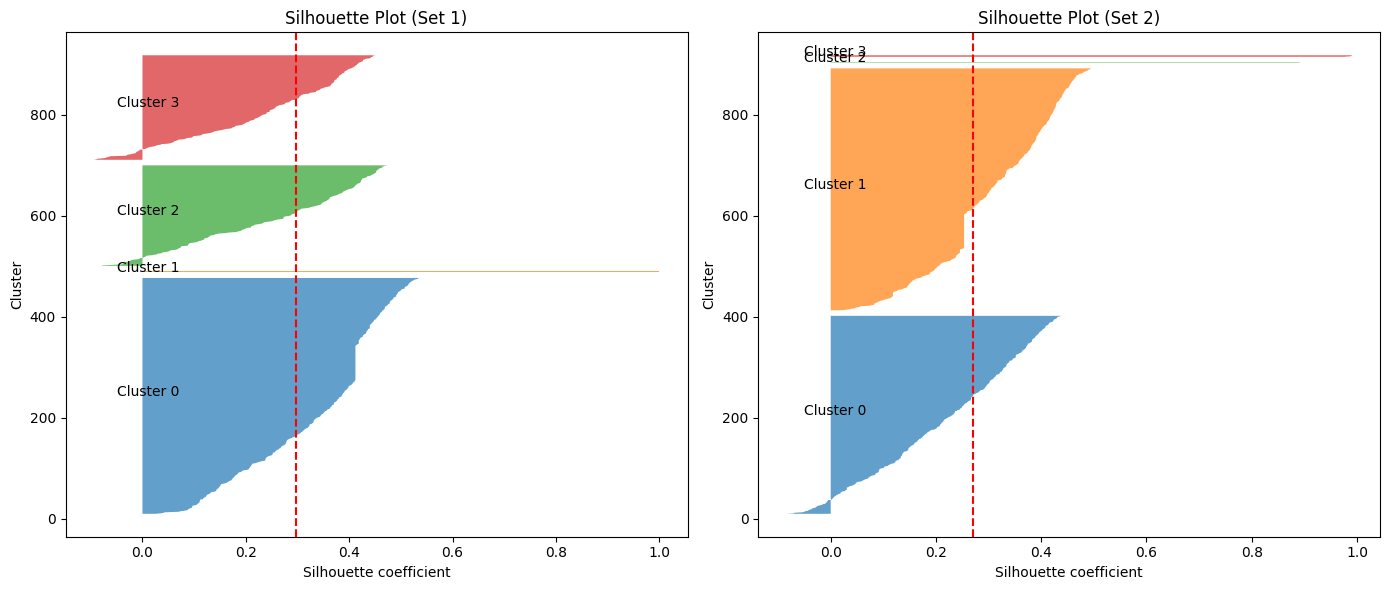

Silhouette médio Set 1: 0.29726536097693373
Silhouette médio Set 2: 0.2704027187856832


In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

datasets = [
    (data_cluster_1, clusters1, "Set 1"),
    (data_cluster_2, clusters2, "Set 2")
]

for ax, (X, labels, title) in zip(axes, datasets):

    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = silhouette_score(X, labels)

    y_lower = 10

    for i in range(4):  # k = 4
        cluster_vals = silhouette_vals[labels == i]
        cluster_vals.sort()

        size_cluster = cluster_vals.shape[0]
        y_upper = y_lower + size_cluster

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_vals,
            alpha=0.7
        )

        ax.text(-0.05, y_lower + 0.5 * size_cluster, f"Cluster {i}")
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(f"Silhouette Plot ({title})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")

plt.tight_layout()
plt.show()

print("Silhouette médio Set 1:", silhouette_score(data_cluster_1, clusters1))
print("Silhouette médio Set 2:", silhouette_score(data_cluster_2, clusters2))

The silhouette plots reveal moderate cluster separation for both feature configurations.

In Feature Set 1, the average silhouette score is approximately 0.30, indicating a reasonable but not strongly defined cluster structure. Most observations exhibit positive silhouette values, suggesting that the majority of institutions are appropriately grouped, although some overlap between clusters remains.

In Feature Set 2, the average silhouette score is slightly lower (≈ 0.27), indicating a comparable but marginally weaker separation between clusters.

Overall, the results suggest that the dataset contains meaningful but partially overlapping institutional groupings, which is expected given the continuous nature of many institutional characteristics.

**Potential Management Implications by Cluster:**

Based on the identified institutional profiles, different strategic considerations may be suggested for each cluster:

- Cluster 0: Institutions with structurally strong profiles and relatively favourable academic outcomes.
 Strategic efforts may focus on maintaining competitive advantages through continued investment in academic selectivity, faculty qualifications, and student support systems.

- Cluster 1: The largest group of institutions with intermediate performance levels.
These institutions could benefit from targeted policies aimed at improving faculty qualifications and reducing the student-faculty ratio, potentially enhancing teaching quality and academic outcomes.

- Cluster 2: Institutions with moderately developed structural characteristics.
Incremental improvements in academic selectivity and student support mechanisms may contribute to gradual improvements in graduation outcomes.

**Comparison with Hierarchical Clustering:**

To assess the robustness of the segmentation obtained with K-Means, an additional clustering approach is applied using Agglomerative Hierarchical Clustering with Ward linkage and the same number of clusters (k = 4).

Comparing results across different clustering algorithms helps evaluate whether the identified institutional groupings represent stable structures in the data rather than artefacts of a specific algorithm.

In [141]:
# Hierarchical Clustering
hier1 = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_hier1 = hier1.fit_predict(data_cluster_1)

hier2 = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_hier2 = hier2.fit_predict(data_cluster_2)

In [142]:
# METRICS
metrics_hier = pd.DataFrame({
    "Dataset": ["Set 1", "Set 2"],
    "Silhouette": [
        silhouette_score(data_cluster_1, labels_hier1),
        silhouette_score(data_cluster_2, labels_hier2)
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(data_cluster_1, labels_hier1),
        calinski_harabasz_score(data_cluster_2, labels_hier2)
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(data_cluster_1, labels_hier1),
        davies_bouldin_score(data_cluster_2, labels_hier2)
    ]
})

**PCA projections for the hierarchical clustering:**

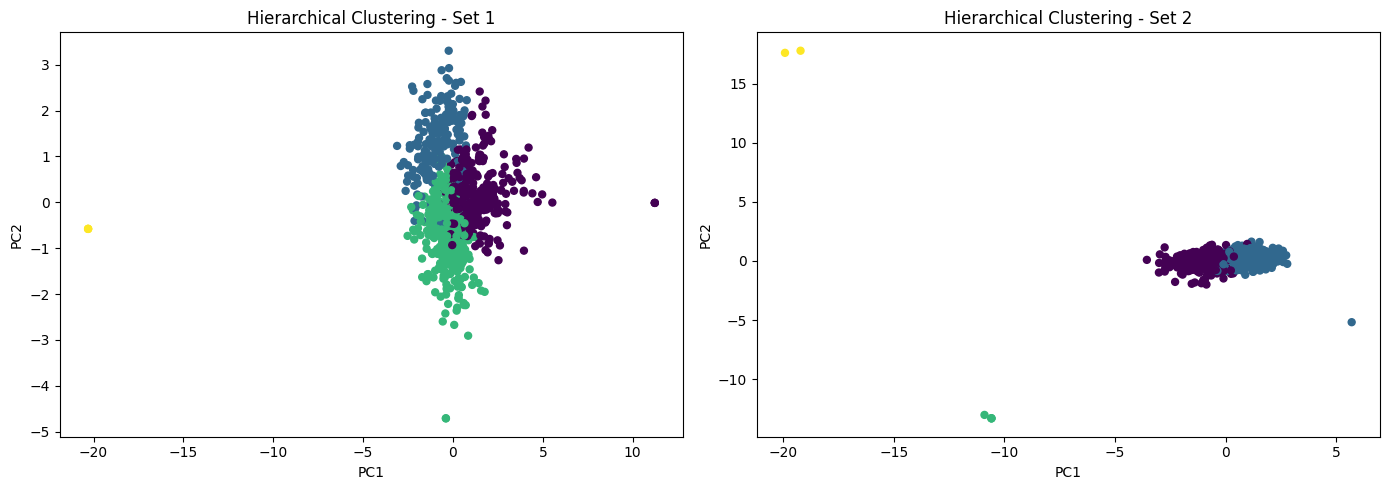

In [143]:
pca1 = PCA(n_components=2)
X1_pca = pca1.fit_transform(data_cluster_1)

pca2 = PCA(n_components=2)
X2_pca = pca2.fit_transform(data_cluster_2)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Set 1
axes[0].scatter(X1_pca[:,0], X1_pca[:,1],
                c=labels_hier1,
                cmap="viridis",
                s=25)

axes[0].set_title("Hierarchical Clustering - Set 1")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Set 2
axes[1].scatter(X2_pca[:,0], X2_pca[:,1],
                c=labels_hier2,
                cmap="viridis",
                s=25)

axes[1].set_title("Hierarchical Clustering - Set 2")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

The PCA projections for the hierarchical clustering reveal spatial patterns similar to those observed with K-Means.

Clusters appear relatively compact but exhibit some degree of overlap, reflecting the gradual variation of institutional characteristics rather than sharply separated groups.

This consistency across algorithms reinforces the robustness of the identified institutional segmentation.

In [144]:
print("Metrics - Hierarchical Clustering")
print(metrics_hier)

Metrics - Hierarchical Clustering
  Dataset  Silhouette  Calinski-Harabasz  Davies-Bouldin
0   Set 1    0.277641         381.106885        0.927068
1   Set 2    0.256694         473.669614        0.799004


In [145]:
metrics["Model"] = "KMeans"
metrics_hier["Model"] = "Hierarchical"

comparison_metrics = pd.concat([metrics, metrics_hier], ignore_index=True)

comparison_metrics.style.highlight_max(subset=["Silhouette","Calinski-Harabasz"])\
                 .highlight_min(subset=["Davies-Bouldin"])


,Dataset,Silhouette,Calinski-Harabasz,Davies-Bouldin,Model
0,Set 1,0.297265,422.859415,0.923841,KMeans
1,Set 2,0.270403,493.242647,0.765102,KMeans
2,Set 1,0.277641,381.106885,0.927068,Hierarchical
3,Set 2,0.256694,473.669614,0.799004,Hierarchical


**Comparison Between K-Means and Hierarchical Clustering:**

The silhouette values obtained for hierarchical clustering are slightly lower than those observed for K-Means, indicating comparable but marginally weaker cluster separation.

However, the PCA visualizations show broadly similar spatial structures across both methods, with clusters appearing relatively compact and partially overlapping. This pattern is typical for real-world institutional datasets, where characteristics tend to vary along continuous gradients.

The consistency between the two clustering approaches suggests that the identified segmentation is not an artefact of the K-Means algorithm, but rather reflects underlying structural patterns present in the dataset.

At the same time, the moderate validation scores indicate that institutional groups are not perfectly separable, highlighting the complexity of higher education systems where multiple structural and contextual factors interact.

## 10) Conclusions and Final Reflection

**What did the exploratory data analysis reveal that changed the initial understanding of the problem?**

The exploratory analysis revealed that the set of institutions is far more heterogeneous than initially expected. Variables related to institutional size and financial resources exhibit strong skewness and several extreme values, which makes comparisons based solely on averages potentially misleading.

The analysis highlighted substantial structural differences between institutions, suggesting that the problem cannot be understood through overly simplified comparisons. In particular, it became evident that academic characteristics such as selectivity and faculty qualifications appear to be more closely associated with academic outcomes than purely financial indicators.

**Which variables appear to be most associated with academic success (graduation rate), and why?**

The variables most strongly associated with graduation rates include the proportion of students from the top 10% and top 25% of their high school class, the percentage of faculty with PhDs, and the student-faculty ratio.

These variables capture key aspects of institutional academic structure, such as student selectivity and teaching capacity. In contrast, financial variables such as expenditure levels showed a weaker association with graduation outcomes, suggesting that simply spending more resources does not necessarily translate into improved academic performance.

Overall, the results indicate that the organization of academic resources and faculty quality may play a more decisive role in student success than the overall volume of financial investment.

**Did the chosen machine learning approach help address the research question?**

The clustering analysis made it possible to identify distinct structural profiles of institutions without directly using graduation rates as an input variable.

When graduation outcomes were analysed across the identified clusters, it became clear that certain institutional profiles tend to be associated with higher academic performance. In particular, clusters characterized by stronger academic selectivity and higher faculty qualifications generally exhibited higher average graduation rates.

Furthermore, the comparison between K-Means and hierarchical clustering produced broadly similar segmentation patterns, suggesting that the identified structure is relatively stable and not dependent on a single algorithm.

These results reinforce the idea that academic success is linked to a combination of institutional characteristics, rather than to any single variable in isolation.

**Limitations and realistic next steps:**

This study has several important limitations. First, the analysis is cross-sectional, which prevents the identification of causal relationships and limits the conclusions to associations between variables.

Additionally, many institutional variables are interrelated and may reflect underlying structural factors such as institutional reputation, funding models, or historical positioning. These hidden factors may generate indirect correlations that are not explicitly captured in the dataset.

Although two clustering algorithms were tested, both methods assume relatively compact cluster structures and may not fully capture more complex patterns present in institutional data.

Future work could extend this analysis by applying supervised learning models to directly predict graduation rates, testing alternative numbers of clusters, or incorporating longitudinal data to study how institutional profiles evolve over time.



---


**Final synthesis:**

Overall, the analysis suggests that academic success in higher education institutions is more strongly associated with structural academic factors, such as student selectivity and faculty qualifications, than with purely financial indicators such as expenditure levels.

The clustering analysis identified distinct institutional profiles that exhibit different academic outcomes, while the comparison of clustering methods confirmed that the segmentation is relatively stable.

However, the moderate separation between clusters and the presence of overlapping characteristics indicate that institutional performance cannot be explained by simple categorical groupings alone.

These results therefore highlight consistent structural patterns in the data, while also emphasizing the complexity of higher education systems and the need for careful interpretation of clustering-based insights.

:)